In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib inline

Compare the workload
Hypothesis: the highest workload and lowest workload processors are predicted correctly.

In [21]:
# Test case
res = 90
procs = 144
case = f"c{res}_p{procs}"

reassign_types = [
    "greedy",
    "nearest_greedy",
    "bilinear_greedy",
    "bicubic_greedy",
]
reassgins = {}

In [22]:
# Read the workload data
workload_df = pd.read_csv(f"test/workloads/c{res}.csv", index_col=0, header=0)

nearest_workload_df = pd.read_csv(
    f"test/workloads/nearest_c24_to_c{res}.csv", index_col=0, header=0
)
bilinear_workload_df = pd.read_csv(
    f"test/workloads/bilinear_c24_to_c{res}.csv", index_col=0, header=0
)
bicubic_workload_df = pd.read_csv(
    f"test/workloads/bicubic_c24_to_c{res}.csv", index_col=0, header=0
)
ml_workload_df = pd.read_csv(
    f"test/workloads/softmax_c{res}_month.csv", index_col=0, header=0
)

# Trim the original workload to match the upscaled intervals
workload_df = workload_df[bilinear_workload_df.columns]

In [23]:
# Trim the machine learning workload to match the upscaled intervals and replace the columns
col_len = min(len(ml_workload_df.columns), len(bilinear_workload_df.columns))
ml_workload_df = ml_workload_df.iloc[:, :col_len]
# Rename the columns to match the upscaled intervals
ml_workload_df.columns = bilinear_workload_df.columns[:col_len]

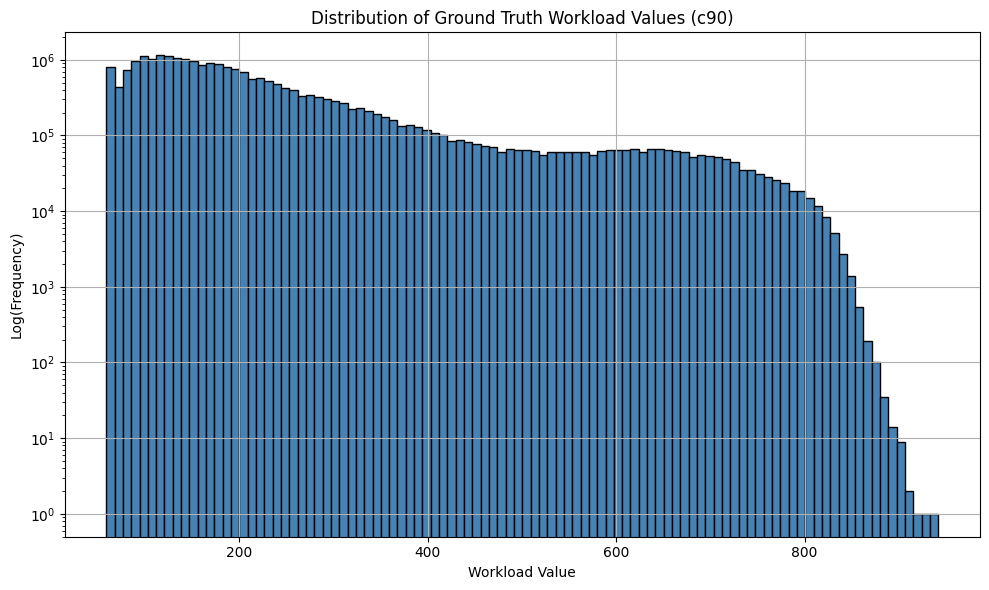

In [24]:
# Flatten all values to a 1D array
flattened_values = workload_df.values.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(flattened_values, bins=100, color="steelblue", edgecolor="black", log=True)
plt.title("Distribution of Ground Truth Workload Values (c90)")
plt.xlabel("Workload Value")
plt.ylabel("Log(Frequency)")
plt.grid(True)
plt.tight_layout()
plt.show()

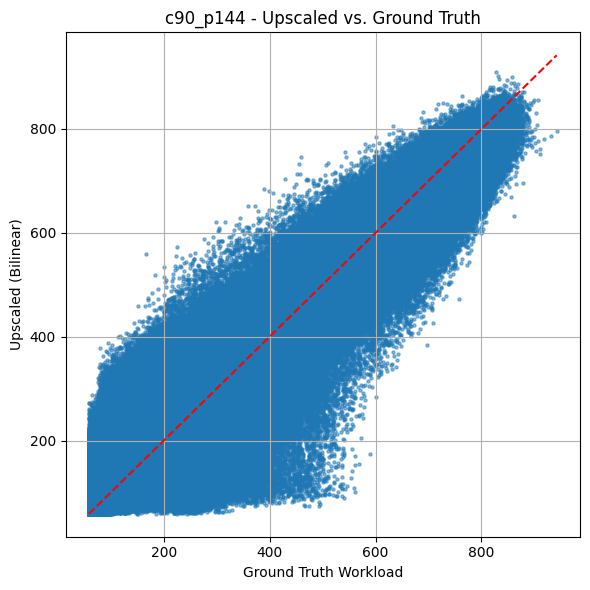

In [25]:
# Repeat the plot for all intervals
x = workload_df.values.flatten()
y = bilinear_workload_df.values.flatten()

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=5)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color="red", linestyle="--")
plt.xlabel("Ground Truth Workload")
plt.ylabel("Upscaled (Bilinear)")
plt.title(f"{case} - Upscaled vs. Ground Truth")
plt.grid(True)
plt.tight_layout()

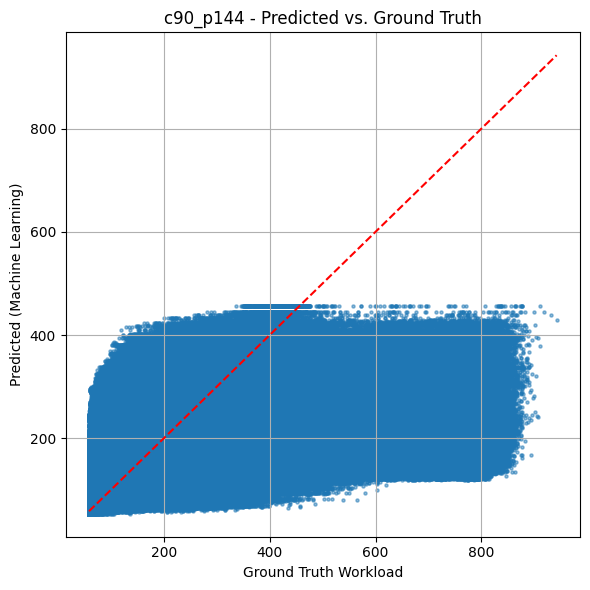

In [26]:
# Repeat the plot for the machine learning workload
x = workload_df.values.flatten()
y = ml_workload_df.values.flatten()

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=5)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color="red", linestyle="--")
plt.xlabel("Ground Truth Workload")
plt.ylabel("Predicted (Machine Learning)")
plt.title(f"{case} - Predicted vs. Ground Truth")
plt.grid(True)
plt.tight_layout()

Analyze the assignment

In [ ]:
# Load the CSV files
og_assign = pd.read_csv(f"test/og_assignments/{case}.csv", index_col=0)
for sim_type in reassign_types:
    file_path = f"test/{sim_type}/{case}/assignment.csv"
    reassgins[sim_type] = pd.read_csv(file_path, index_col=0)

# Trim the original dataframe to match the upscaled intervals
upscaled_df = reassgins["bilinear_greedy"]
original_df = reassgins["greedy"]
original_df = original_df[upscaled_df.columns]

# Rename the columns to match the upscaled intervals
nintervals = len(upscaled_df.columns)
intervals = range(nintervals)
upscaled_df.columns = intervals
original_df.columns = intervals

In [4]:
# Compute the workload for each processor at each interval using the original assignments
def compute_workload(
    workload_df: pd.DataFrame, og_assign: pd.DataFrame, procs: int
) -> pd.DataFrame:
    """
    Compute the workload for each processor at each interval.
    """
    _, intervals = workload_df.shape
    workload = np.zeros((procs, intervals), dtype=float)
    assigned_procs = og_assign.values.flatten()

    for interval in range(intervals):
        np.add.at(
            workload[:, interval], assigned_procs, workload_df.values[:, interval]
        )

    return pd.DataFrame(workload, index=range(procs), columns=workload_df.columns)

In [ ]:
# Track the target processor the original and reassignment decide to assign for each processor at each interval
# Also track how many times it is assigned to that processor
# Assuming there is up to one target processor per processor at each interval
def count_assignments(
    assign: pd.DataFrame, og_assign: pd.DataFrame, procs: int
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Count the number of assignments for each processor at each interval.
    """
    samples, intervals = assign.shape
    counts = np.zeros((procs, intervals), dtype=int)
    targets = -np.ones((procs, intervals), dtype=int)

    # Expand original assignments to match shape of assign
    og_expanded = np.tile(og_assign.values, (1, intervals))

    # Mask where assignments differ
    mask = assign.values != og_expanded

    # Get processor indices and interval indices where reassignment occurred
    reassigned_proc = assign.values[mask]
    original_proc = og_expanded[mask]
    interval_idx = np.tile(np.arange(intervals), samples)[mask.ravel()]

    # Count assignments and set targets
    for proc, orig, idx in zip(reassigned_proc, original_proc, interval_idx):
        counts[proc, idx] += 1
        targets[proc, idx] = orig

    return pd.DataFrame(
        counts, index=range(procs), columns=assign.columns
    ), pd.DataFrame(targets, index=range(procs), columns=assign.columns)

In [ ]:
# Count it for greedy heuristic on both the original and upscaled workloads
og_counts, og_targets = count_assignments(original_df, og_assign, procs)

# Print the first interval of the counts and targets
print("Original workload counts:", og_counts.iloc[:, 0].values)
print("Original workload targets:", og_targets.iloc[:, 0].values)

In [ ]:
upscaled_counts, upscaled_targets = count_assignments(upscaled_df, og_assign, procs)

print("Upscaled workload counts:", upscaled_counts.iloc[:, 0].values)
print("Upscaled workload targets:", upscaled_targets.iloc[:, 0].values)

In [ ]:
# Tally for each interval, how many times does the upscaled workload assigns to a different processor than the original workload
target_diff = upscaled_targets != og_targets
target_diff_count = target_diff.sum(axis=0)

print("Target difference counts:", target_diff_count.values)

In [ ]:
# Absolute difference
abs_diff_correct = np.abs(
    bilinear_max_values[correct_predictions] - og_max_values[correct_predictions]
)
abs_diff_all = np.abs(bilinear_max_values - og_max_values)


abs_diff_table = pd.DataFrame(
    {
        "mean": [np.mean(abs_diff_correct), np.mean(abs_diff_all)],
        "std": [np.std(abs_diff_correct), np.std(abs_diff_all)],
        "min": [np.min(abs_diff_correct), np.min(abs_diff_all)],
        "max": [np.max(abs_diff_correct), np.max(abs_diff_all)],
        "median": [np.median(abs_diff_correct), np.median(abs_diff_all)],
    },
    index=["Correct", "All"],
)
print(abs_diff_table)

In [ ]:
# Absolute ratio deviation
ratios_correct = (
    bilinear_max_values[correct_predictions] / og_max_values[correct_predictions]
)
ratios_all = bilinear_max_values / og_max_values
abs_ratio_dev_correct = np.abs(ratios_correct - 1)
abs_ratio_dev_all = np.abs(ratios_all - 1)

abs_ratio_table = pd.DataFrame(
    {
        "mean": [
            abs_ratio_dev_correct.mean(),
            abs_ratio_dev_all.mean(),
        ],
        "std": [
            np.std(abs_ratio_dev_correct),
            np.std(abs_ratio_dev_all),
        ],
        "min": [
            np.min(abs_ratio_dev_correct),
            np.min(abs_ratio_dev_all),
        ],
        "median": [
            np.median(abs_ratio_dev_correct),
            np.median(abs_ratio_dev_all),
        ],
        "max": [
            np.max(abs_ratio_dev_correct),
            np.max(abs_ratio_dev_all),
        ],
    },
    index=["Correct", "All"],
)
print(abs_ratio_table)

In [ ]:
# Now rather than just comparing the max workload per processor, compare the entire workload
# Compute the absolute difference between the bilinear and original workloads, and summarize the results
abs_diff_workload = np.abs(bilinear_workload.values - og_workload.values)
abs_diff_workload_df = pd.DataFrame(
    abs_diff_workload, index=range(procs), columns=workload_df.columns
)
abs_diff_workload_summary = abs_diff_workload_df.describe().T
# Drop the count, 25%, and 75% columns, and rename the 50% column to median
abs_diff_workload_summary.drop(columns=["count", "25%", "75%"], inplace=True)
abs_diff_workload_summary.rename(
    columns={
        "50%": "median",
    },
    inplace=True,
)
print(abs_diff_workload_summary)

In [ ]:
# Repeat the same for the ratios
ratios_workload = bilinear_workload.values / og_workload.values
ratios_workload_df = pd.DataFrame(
    ratios_workload, index=range(procs), columns=workload_df.columns
)
ratios_workload_summary = ratios_workload_df.describe().T
# Drop the count, 25%, and 75% columns, and rename the 50% column to median
ratios_workload_summary.drop(columns=["count", "25%", "75%"], inplace=True)
ratios_workload_summary.rename(
    columns={
        "50%": "median",
    },
    inplace=True,
)
print(ratios_workload_summary)

In [ ]:
# And absolute ratio deviation
abs_ratio_dev_workload = np.abs(ratios_workload - 1)
abs_ratio_dev_workload_df = pd.DataFrame(
    abs_ratio_dev_workload, index=range(procs), columns=workload_df.columns
)
abs_ratio_dev_workload_summary = abs_ratio_dev_workload_df.describe().T
# Drop the count, 25%, and 75% columns, and rename the 50% column to median
abs_ratio_dev_workload_summary.drop(columns=["count", "25%", "75%"], inplace=True)
abs_ratio_dev_workload_summary.rename(
    columns={
        "50%": "median",
    },
    inplace=True,
)
print(abs_ratio_dev_workload_summary)

In [ ]:
from scipy.stats import spearmanr

def compute_spearman_correlation(
    og_workload_df: pd.DataFrame, workload_df: pd.DataFrame, og_assign: pd.DataFrame
) -> pd.DataFrame:
    """
    Compute Spearman correlation between ground truth and predicted workload,
    grouped by processor and interval.
    Returns a DataFrame of shape (intervals, procs).
    """
    _, intervals = workload_df.shape
    procs = int(og_assign.values.max()) + 1
    assignments = og_assign.values.flatten()

    correlations = np.full((intervals, procs), np.nan, dtype=float)

    # Pre-convert to NumPy arrays for performance
    og_values = og_workload_df.values
    pred_values = workload_df.values

    for proc in range(procs):
        mask = assignments == proc
        if np.sum(mask) < 2:
            continue  # Not enough data to compute correlation
        og_proc = og_values[mask]
        pred_proc = pred_values[mask]
        for t in range(intervals):
            corr, _ = spearmanr(og_proc[:, t], pred_proc[:, t])
            correlations[t, proc] = corr

    return pd.DataFrame(correlations, columns=[f"Proc {p}" for p in range(procs)])


# Compute the Spearman correlation for the bilinear workload
nearest_spearman = compute_spearman_correlation(
    workload_df, nearest_workload_df, og_assign
)
bilinear_spearman = compute_spearman_correlation(
    workload_df, bilinear_workload_df, og_assign
)
bicubic_spearman = compute_spearman_correlation(
    workload_df, bicubic_workload_df, og_assign
)
print(bilinear_spearman)

In [ ]:
# Summarize the Spearman correlation
nearest_spearman_summary = pd.DataFrame(nearest_spearman.values.flatten()).describe()
nearest_spearman_summary.drop(index=["count"], inplace=True)
nearest_spearman_summary.rename(
    index={
        "25%": "q1",
        "50%": "median",
        "75%": "q3",
    },
    inplace=True,
)

bilinear_spearman_summary = pd.DataFrame(bilinear_spearman.values.flatten()).describe()
bilinear_spearman_summary.drop(index=["count"], inplace=True)
bilinear_spearman_summary.rename(
    index={
        "25%": "q1",
        "50%": "median",
        "75%": "q3",
    },
    inplace=True,
)

bicubic_spearman_summary = pd.DataFrame(bicubic_spearman.values.flatten()).describe()
bicubic_spearman_summary.drop(index=["count"], inplace=True)
bicubic_spearman_summary.rename(
    index={
        "25%": "q1",
        "50%": "median",
        "75%": "q3",
    },
    inplace=True,
)

# Combine the summaries into a single DataFrame
spearman_summary = pd.concat(
    [nearest_spearman_summary, bilinear_spearman_summary, bicubic_spearman_summary],
    axis=1,
)
spearman_summary.columns = ["nearest", "bilinear", "bicubic"]
# Print the summary statistics
print(spearman_summary.to_csv(sep=",", index_label=case))

In [ ]:
# Plot the Spearman correlation with intervals as the x-axis
def plot_spearman_correlation(
    spearman_df: pd.DataFrame, title: str, case: str
) -> None:
    """
    Plot the Spearman correlation for each processor over time.
    """
    plt.figure(figsize=(12, 6))
    plt.margins(x=0)
    for proc in range(spearman_df.shape[1]):
        plt.scatter(spearman_df.index, spearman_df.iloc[:, proc], label=f"Proc {proc}", alpha=0.5, s=10)
    plt.title(f"{title} - {case}")
    plt.xlabel("Interval")
    plt.ylabel("Spearman Correlation")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

plot_spearman_correlation(bilinear_spearman, "Bilinear Spearman Correlation", case)

In [ ]:
# Plot the Spearman correlation with processor as the x-axis
def plot_spearman_correlation_by_processor(
    spearman_df: pd.DataFrame, title: str, case: str
) -> None:
    """
    Plot the Spearman correlation for each interval over processors.
    """
    plt.figure(figsize=(30, 6))
    plt.margins(x=0)
    for interval in range(spearman_df.shape[0]):
        plt.scatter(
            spearman_df.columns,
            spearman_df.iloc[interval, :],
            label=f"Interval {interval}",
            alpha=0.5,
            s=10,
        )
    plt.title(f"{title} - {case}")
    plt.xlabel("Processor")
    plt.xticks(rotation=90)
    plt.ylabel("Spearman Correlation")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
plot_spearman_correlation_by_processor(bilinear_spearman, "Bilinear Spearman Correlation", case)

In [ ]:
# Plot the Spearman correlation as a heatmap with intervals as the x-axis and processors as the y-axis
def plot_spearman_correlation_heatmap(
    spearman_df: pd.DataFrame, title: str, case: str
) -> None:
    """
    Plot the Spearman correlation as a heatmap.
    """
    # Calculate square aspect figure size
    height = spearman_df.shape[1]  # processors (Y)
    width = spearman_df.shape[0]  # intervals (X)
    cell_size = 0.1  # increase for bigger cells

    fig_width = width * cell_size
    fig_height = height * cell_size

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    cax = ax.imshow(
        spearman_df.T, aspect="auto", cmap="viridis", interpolation="nearest"
    )
    cbar = fig.colorbar(cax, ax=ax, shrink=0.8, pad=0.02, aspect=30)
    cbar.set_label("Spearman Correlation", fontsize=12)

    # Labels and title
    ax.set_title(f"{title} - {case}", fontsize=14)
    ax.set_xlabel("Interval", fontsize=12)
    ax.set_ylabel("Processor", fontsize=12)

    # Ticks every 6 intervals or processors
    ax.set_xticks(np.arange(0, spearman_df.shape[0], 5))
    ax.set_yticks(np.arange(0, spearman_df.shape[1], 5))
    ax.set_yticklabels([f"Proc {i}" for i in range(0, spearman_df.shape[1], 5)])

    plt.tight_layout()
    plt.show()


plot_spearman_correlation_heatmap(bilinear_spearman, "Bilinear Spearman Correlation", case)

In [ ]:
# Print the processor intervals where the Spearman correlation is less than 0
def print_negative_spearman(spearman_df: pd.DataFrame, label: str):
    neg_indices = np.argwhere(spearman_df.values < 0)
    if len(neg_indices) == 0:
        print(f"[{label}] No negative Spearman correlations found.")
    else:
        print(f"[{label}] Negative Spearman correlations at (interval, processor):")
        for interval, proc in neg_indices:
            corr = spearman_df.iat[interval, proc]
            print(f"  Interval {interval}, Processor {proc}: {corr:.4f}")

print_negative_spearman(nearest_spearman, "nearest")
print_negative_spearman(bilinear_spearman, "bilinear")
print_negative_spearman(bicubic_spearman, "bicubic")

In [ ]:
# Compute the spearman correlation for each interval
def compute_spearman_correlation(
    og_workload: pd.DataFrame, pred_workload: pd.DataFrame
) -> pd.Series:
    """
    Compute the spearman correlation for each interval.
    """
    correlations = [
        spearmanr(og_workload.iloc[:, i].values, pred_workload.iloc[:, i].values)[0]
        for i in range(og_workload.shape[1])
    ]
    return pd.Series(correlations)

# Compute the spearman correlation
nearest_correlation = compute_spearman_correlation(workload_df, nearest_workload_df)
bilinear_correlation = compute_spearman_correlation(workload_df, bilinear_workload_df)
bicubic_correlation = compute_spearman_correlation(workload_df, bicubic_workload_df)

# Summary statistics
nearest_correlation_summary = nearest_correlation.describe()
nearest_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
nearest_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)
bilinear_correlation_summary = bilinear_correlation.describe()
bilinear_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
bilinear_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)
bicubic_correlation_summary = bicubic_correlation.describe()
bicubic_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
bicubic_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

# Combine all summaries into a single table
correlation_table = pd.DataFrame(
    {
        "nearest": nearest_correlation_summary,
        "bilinear": bilinear_correlation_summary,
        "bicubic": bicubic_correlation_summary,
    }
)

# Print the table with comma as separator
print(correlation_table.to_string(index=True, header=True, float_format="%.3f"))

In [ ]:
from scipy.stats import pearsonr

# Compute the pearson correlation for each interval
def compute_pearson_correlation(
    og_workload: pd.DataFrame, pred_workload: pd.DataFrame
) -> pd.Series:
    """
    Compute the pearson correlation for each interval.
    """
    correlations = [
        pearsonr(og_workload.iloc[:, i].values, pred_workload.iloc[:, i].values)[0]
        for i in range(og_workload.shape[1])
    ]
    return pd.Series(correlations)

# Compute the pearson correlation
nearest_pearson_correlation = compute_pearson_correlation(workload_df, nearest_workload_df)
bilinear_pearson_correlation = compute_pearson_correlation(workload_df, bilinear_workload_df)
bicubic_pearson_correlation = compute_pearson_correlation(workload_df, bicubic_workload_df)

# Summary statistics
nearest_pearson_correlation_summary = nearest_pearson_correlation.describe()
nearest_pearson_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
nearest_pearson_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

bilinear_pearson_correlation_summary = bilinear_pearson_correlation.describe()
bilinear_pearson_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
bilinear_pearson_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

bicubic_pearson_correlation_summary = bicubic_pearson_correlation.describe()
bicubic_pearson_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
bicubic_pearson_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

# Combine all summaries into a single table
pearson_correlation_table = pd.DataFrame(
    {
        "nearest": nearest_pearson_correlation_summary,
        "bilinear": bilinear_pearson_correlation_summary,
        "bicubic": bicubic_pearson_correlation_summary,
    }
)
# Print the table with comma as separator
print(pearson_correlation_table.to_string(index=True, header=True, float_format="%.3f"))

In [ ]:
# Plot the bilinear correlation with intervals as the x-axis as a line plot
plt.figure(figsize=(12, 6))
plt.margins(x=0)
plt.plot(
    bilinear_correlation.index,
    bilinear_correlation.values,
    label="Bilinear",
    alpha=0.5,
    linewidth=2,
)
plt.title(f"Bilinear Spearman Correlation - {case}")
plt.xlabel("Interval")
plt.ylabel("Spearman Correlation")
plt.ylim(0.9, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# It seems like there is a dip every 9 intervals starting at 0, then 9, 18, etc.
# Plot the line plot without those intervals
plt.figure(figsize=(12, 6))
plt.margins(x=0)
plt.plot(
    bilinear_correlation.index[bilinear_correlation.index % 9 != 0],
    bilinear_correlation.values[bilinear_correlation.index % 9 != 0],
    label="Non-reading intervals",
    alpha=0.5,
    linewidth=2,
)
# Plot another line for the intervals that were removed
plt.plot(
    bilinear_correlation.index[bilinear_correlation.index % 9 == 0],
    bilinear_correlation.values[bilinear_correlation.index % 9 == 0],
    label="Reading intervals",
    alpha=0.5,
    linewidth=2,
    linestyle="--",
)
plt.legend()
plt.title(f"Bilinear Spearman Correlation - {case}")
plt.xlabel("Interval")
plt.ylabel("Spearman Correlation")
plt.ylim(0.9, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
interval = 0  # start with a representative interval
x = workload_df.iloc[:, interval].array
y = bilinear_workload_df.iloc[:, interval].array

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=5)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color="red", linestyle="--")
plt.xlabel("Ground Truth Workload")
plt.ylabel("Upscaled (Bilinear)")
plt.title(f"C{res} - Upscaled vs. Ground Truth (Interval {interval})")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Repeat it but using data from all intervals
x = workload_df.values.flatten()
y = bilinear_workload_df.values.flatten()
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=5)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color="red", linestyle="--")
plt.xlabel("Ground Truth Workload")
plt.ylabel("Upscaled (Bilinear)")
plt.title(f"C{res} - Upscaled vs. Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

Compare the simulated workspan

In [ ]:
# Read all the simulation data
simulation_types = ["original", "greedy", "nearest_greedy", "bilinear_greedy", "bicubic_greedy"]
simulations = {}

for sim_type in simulation_types:
    if sim_type == "original":
        file_path = f"test/og_assignments/{case}_simulation.csv"
    else:
        file_path = f"test/{sim_type}/{case}/simulation.csv"
    simulations[sim_type] = pd.read_csv(file_path)

In [ ]:
# Generate an animation showing the workload distribution for all the simulation types
fig, ax = plt.subplots(figsize=(160, 6))
bar_width = 0.15
bars = []

# Exclude 'Interval' column and the last 4 Max,Mean,SD,CV columns
ylim = max(simulations[simulation_types[i]].iloc[:, 1:-4].max().max() * 1.1 for i in range(len(simulation_types)))
xlabels = simulations[simulation_types[0]].columns[1:-4]
x = np.arange(len(xlabels))

def init():
    ax.clear()
    ax.margins(x=0)
    ax.set_ylim(0, ylim)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=90)
    ax.set_ylabel("Workload")
    ax.set_title("Workload Distribution per Processor")
    fig.tight_layout()
    return bars

def update(frame):
    ax.clear()
    ax.margins(x=0)
    for i, sim_type in enumerate(simulation_types):
        sim_data = simulations[sim_type]
        workloads = sim_data.iloc[frame, 1:-4]
        bar = ax.bar(x + i * bar_width, workloads, bar_width, label=sim_type)
        bars.append(bar)
    # Plot a dotted reference line for the mean workload
    mean = simulations[simulation_types[0]].iloc[frame, -3]
    ax.axhline(mean, color="red", linestyle="--", label="Mean Workload")

    ax.set_ylim(0, ylim)
    ax.set_xticks(x + bar_width * (len(simulation_types)-1)/2)
    ax.set_xticklabels(xlabels, rotation=90)
    ax.set_ylabel("Workload")
    ax.set_title(f"Workload Distribution per Processor (Interval {frame})")
    ax.legend(
        loc="upper right",
        title="Simulation Type",
        fontsize="small",
    )
    fig.tight_layout()
    return bars

ani = FuncAnimation(
    fig,
    update,
    frames=range(len(simulations[simulation_types[0]])),
    init_func=init,
    blit=False,
)

ani.save(f"{case}_anim.gif", writer="imagemagick")